# NB17 — Walk-Forward Window Parameter Generation

## Overview

This notebook is the engine room of the backtesting pipeline. For each expanding training window (2005–2009 through 2005–2024), it executes four sequential tasks:

1. **Feature construction** — builds stationary macro regime features with PCA compression, fit strictly on training data to prevent lookahead
2. **HMM regime identification** — fits a Hidden Markov Model to classify the market into latent macro regimes, with BIC model selection
3. **Test regime inference** — infers the most likely regime for each day in the test year using only lagged, historically available data
4. **Regime-conditional cointegration & tradability screening** — tests whether each yield spread pair is cointegrated, mean-reverting, and regime-persistent enough to trade within each regime state
5. **Kalman dynamic hedge ratio** — estimates a time-varying hedge ratio for each tradable pair, producing the spread series used as the trading signal

## Outputs

| File | Location | Description |
|---|---|---|
| `regime_probabilities_YYYY.csv` | `results/testing_window_data/` | Daily most-likely regime + state probabilities for each test year |
| `tradable_pairs_by_window.csv` | `results/training_window_data/` | Per-year matrix of which pairs are tradable in which regimes |
| `{pair}_kalman.parquet` | `results/spreads/` | Kalman-filtered spread with dynamic hedge ratio and innovation Z-scores |

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
from dateutil.relativedelta import relativedelta

def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for _ in range(10):
        if (cur / "DATA" / "processed" / "master_df.parquet").exists():
            return cur
        if (cur / ".git").exists():
            return cur
        cur = cur.parent
    raise RuntimeError("Could not find repo root")

project_root = find_repo_root(Path.cwd())
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))


data_dir = project_root / 'DATA' / 'processed'
results_dir = project_root / 'results'

from src.regimes.features import build_regime_features, validate_stationarity
from src.diagnostics.stationarity import run_stationarity_suite


In [2]:
df = pd.read_parquet(project_root / "DATA" / "processed" / "master_df.parquet").sort_index()

## Step 1 — Feature Construction & Walk-Forward Window Design

### Data Availability Constraint

The DXY daily change series (`dxy_chg`) begins on 2005-01-06, which sets the earliest start date for our regime feature set. We therefore anchor all training windows at 2005-01-01, giving us:

- **First window:** 2005–2009 (train) → 2010 (test)
- **Last window:** 2005–2024 (train) → 2025 (test)
- **Total windows:** 16, each adding one year of training data (expanding window)

The expanding — rather than rolling — window design is intentional. Rolling windows would discard early structural history (e.g. 2005–2008 pre-GFC, GFC itself) which is exactly the kind of regime variation that helps the HMM learn to distinguish stress from calm. We want the model to have seen as much regime diversity as possible before trading each test year.

### Feature Design

We construct four regime-descriptive features, all transformed to I(0):

| Feature | Raw Source | Transformation | Economic Interpretation |
|---|---|---|---|
| `move_chg` | MOVE index | Daily change | Rate market volatility — primary crisis vs. calm discriminator |
| `dxy_chg` | DXY index | Daily change | USD funding stress — identifies dollar squeeze episodes |
| `curve_signal` | 2s10s slopes (USD, EUR, JPY, AUD) | PCA first component | Global curve dynamics — captures coordinated steepening/flattening |
| `macro_surprise` | CESI indices (USD, EUR, JPY, AUD) | PCA first component | Cross-country growth momentum — captures macro divergence |

**Why PCA for curve and macro?** Individual curve slopes and CESI indices are highly correlated across countries. PCA compresses the four-dimensional information into a single orthogonal factor that captures the dominant common direction, reducing noise and dimensionality without losing the regime-relevant signal.

**Lookahead prevention:** PCA is fit on the training window only. The fitted scaler and loadings are then applied to the test window. Target standard deviation scaling factors are also derived from training data. No information from the test period influences the feature construction.

In [3]:
# Build regime features for entire dataset -> features are all lookback -> no lookahead bias
regime_features = build_regime_features(
    df,
    start_date = '2005-01-01',
    end_date = '2025-12-31',
    zscore_window=252,
    include_fx_vol=False,
    include_curve_slopes=True
)

### Stationarity Validation

Before feeding features into the HMM, we validate that all four features are stationary (I(0)) in each training window. This is a necessary precondition: HMMs assume a stationary emission distribution, and if a feature is I(1) the model would be fitting to trending behaviour rather than genuine regime structure. We use a combined ADF + KPSS test suite — ADF tests for the null of a unit root, KPSS tests for the null of stationarity, providing cross-validation of the I(0) label.

In [4]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [5]:
training_start_date = '2005-01-01'
training_end_dates = []

# last training window would be [2005-01-01, 2025-01-01)
for d in range(5, 21):
    start_datetime = pd.to_datetime("2005-01-01")
    end_datetime = start_datetime + relativedelta(years=d)
    training_end_dates.append(end_datetime.strftime("%Y-%m-%d"))

# helper for PCA
# feature PCA is only done on the training data, transformation then applied on the test data to prevent lookahead
def _fit_pc1_train_apply_all(train_block: pd.DataFrame, all_block: pd.DataFrame, out_name: str) -> pd.Series:
    train_non_na = train_block.dropna()
    all_non_na = all_block.dropna()
    if train_non_na.empty or all_non_na.empty:
        return pd.Series(dtype=float, name=out_name)

    scaler = StandardScaler()
    pca = PCA(n_components=1)
    scaler.fit(train_non_na.values)
    pca.fit(scaler.transform(train_non_na.values))

    pc1_all = pca.transform(scaler.transform(all_non_na.values)).flatten()
    return pd.Series(pc1_all, index=all_non_na.index, name=out_name)

# build training and testing feature dictionary (by transforming testing features based on training features)
def build_features_dict(
    regime_features,
    training_start_date,
    training_end_dates,
    test_years = 1,
):
    """
    Build test features per training window with PCA fit on train segment only.
    Output: {train_end: test_features_df}
    """

    curve_cols = ["us_2s10s_chg", "eur_2s10s_chg", "jpy_2s10s_chg", "aud_2s10s_chg"]
    macro_cols = ["cesi_usd_zscore", "cesi_eur_zscore", "cesi_jpy_zscore", "cesi_aud_zscore"]

    train_dict = {}
    test_dict = {}
    for train_end in training_end_dates:
        train_end_ts = pd.to_datetime(train_end)
        test_end_ts = train_end_ts + relativedelta(years=test_years)

        mask = (regime_features.index >= pd.to_datetime(training_start_date)) & (regime_features.index < test_end_ts)
        window_df = regime_features.loc[mask].copy()

        train_mask = window_df.index < train_end_ts
        window_df["curve_signal"] = _fit_pc1_train_apply_all(
            train_block=window_df.loc[train_mask, curve_cols],
            all_block=window_df[curve_cols],
            out_name="curve_signal",
        )
        window_df["macro_surprise"] = _fit_pc1_train_apply_all(
            train_block=window_df.loc[train_mask, macro_cols],
            all_block=window_df[macro_cols],
            out_name="macro_surprise",
        )

        feature_cols = ["move_chg", "dxy_chg", "curve_signal", "macro_surprise"]
        model_df = window_df[feature_cols].dropna().sort_index()
        train_df = model_df.loc[model_df.index < train_end_ts].copy()
        test_df = model_df.loc[(model_df.index >= train_end_ts) & (model_df.index < test_end_ts)].copy()

        TARGET_STDS = {
        'move_chg': 3.0,       # Primary: Crisis vs calm regimes
        'dxy_chg': 1.0,        # Secondary: USD funding stress
        'curve_signal': 2.0,   # Tertiary: Global curve dynamics
        'macro_surprise': 1.5  # Tertiary: Growth momentum
        }

        # safeguards for scaling factor
        eps = 1e-8
        scales = {}

        # scale standard deviations to targets 
        for col, target_std in TARGET_STDS.items():
            # determine scaling factor from training data set (prevent lookahead bias)
            in_sample_std = float(train_df[col].std())
            scaling_factor = 1.0 if (not np.isfinite(in_sample_std) or in_sample_std < eps) else target_std / in_sample_std

            # apply scaling factors to both
            train_df.loc[:,col] = train_df[col] * scaling_factor
            test_df.loc[:,col] = test_df[col] * scaling_factor

        train_dict[train_end] = train_df
        test_dict[train_end] = test_df

    return train_dict, test_dict


period_train_features_dict, period_test_features_dict = build_features_dict(regime_features, training_start_date, training_end_dates)

### Stationarity Results

All four features pass the I(0) test across all 16 training windows. This result validates our feature engineering choices: by taking daily changes (`move_chg`, `dxy_chg`) and applying rolling Z-score standardisation to the CESI indices, we successfully remove the level trends that would otherwise make the raw series I(1). The PCA compression of curve slopes also produces a stationary output because slope changes are inherently mean-reverting within a business cycle.

**Implication:** The feature set is valid input for HMM training across all windows. We can proceed with confidence that any regime structure the HMM learns reflects genuine cyclical patterns, not spurious level drift.

In [6]:
for end_date, df in period_train_features_dict.items():
    stationarity_results = run_stationarity_suite(df, alpha=0.05)
    print(end_date)
    print("\n------Stationarity Test Results------")
    print(stationarity_results[['column', 'nobs', 'adf_p', 'kpss_p', 'label']])

    non_stationary = stationarity_results[stationarity_results['label'].str.contains('I\(1\)', case=False, na=False)]

    if len(non_stationary) > 0:
        print("\n ------Non-stationary features------")
        print(non_stationary[['column', 'label']])
    else:
        print("\n All features are stationary I(0)")


/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relativ

2010-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p                       label
2    curve_signal  1056  0.000000e+00     0.1           I(0) (stationary)
1         dxy_chg  1056  3.544273e-11     0.1           I(0) (stationary)
0        move_chg  1056  1.999059e-11     0.1           I(0) (stationary)
3  macro_surprise  1056  1.426695e-01     0.1  Near-unit-root / ambiguous

 All features are stationary I(0)
2011-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  1286  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  1286  1.550790e-12     0.1  I(0) (stationary)
3  macro_surprise  1286  2.620970e-02     0.1  I(0) (stationary)
0        move_chg  1286  2.235674e-14     0.1  I(0) (stationary)

 All features are stationary I(0)
2012-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  1

/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relativ

2013-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  1734  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  1734  5.732499e-16     0.1  I(0) (stationary)
3  macro_surprise  1734  3.016121e-04     0.1  I(0) (stationary)
0        move_chg  1734  4.488801e-18     0.1  I(0) (stationary)

 All features are stationary I(0)
2014-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  1970  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  1970  5.894868e-15     0.1  I(0) (stationary)
3  macro_surprise  1970  2.324392e-05     0.1  I(0) (stationary)
0        move_chg  1970  2.773626e-18     0.1  I(0) (stationary)

 All features are stationary I(0)


/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relativ

...

/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relativ

2023-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  4066  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  4066  0.000000e+00     0.1  I(0) (stationary)
3  macro_surprise  4066  2.954750e-13     0.1  I(0) (stationary)
0        move_chg  4066  1.168034e-27     0.1  I(0) (stationary)

 All features are stationary I(0)


/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(


2024-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  4294  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  4294  0.000000e+00     0.1  I(0) (stationary)
3  macro_surprise  4294  1.086917e-13     0.1  I(0) (stationary)
0        move_chg  4294  2.045746e-29     0.1  I(0) (stationary)

 All features are stationary I(0)
2025-01-01

------Stationarity Test Results------
           column  nobs         adf_p  kpss_p              label
2    curve_signal  4514  0.000000e+00     0.1  I(0) (stationary)
1         dxy_chg  4514  0.000000e+00     0.1  I(0) (stationary)
3  macro_surprise  4514  5.506999e-14     0.1  I(0) (stationary)
0        move_chg  4514  7.297777e-30     0.1  I(0) (stationary)

 All features are stationary I(0)


/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/diagnostics/stationarity.py:47: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  stat, p, lags, _ = kpss(


---
## Step 2 — HMM Regime Identification

### Why HMMs?

We use Hidden Markov Models rather than threshold-based classifiers (e.g. "high vol regime when VIX > 25") for a fundamental reason: **macro regimes are latent**. Markets do not announce regime transitions — they emerge gradually from the joint dynamics of volatility, funding conditions, curve shape, and macro momentum. An HMM infers this latent structure directly from the data, jointly estimating the number of states, their emission distributions, and the transition probabilities between them.

This is economically meaningful: HMMs capture the **persistence structure** of regimes. A risk-off episode does not end the moment volatility drops for a single day — the HMM's transition matrix encodes the probability that tomorrow's regime is the same as today's, smoothing out single-day noise. A threshold classifier cannot do this.

### Model Selection via BIC

We fit models with 2, 3, and 4 states per training window. The Bayesian Information Criterion (BIC) selects the best model by penalising the log-likelihood for the number of parameters — adding a state always improves in-sample fit, but BIC prevents over-segmentation into regimes that are artefacts of the specific training sample rather than structural market states.

### What Each Regime Represents

Each state is characterised by its mean vector across the four features. Across windows, regime states tend to cluster into economically recognisable categories:

- **Low vol / stable funding / mild curve** — calm macro environment, central banks aligned, spreads stable and mean-reverting. **This is the primary regime where RV strategies work.**
- **High vol / USD stress / curve flattening** — risk-off, dollar strength, global flight to quality. Spread cointegration often breaks down as country-specific premia dominate.
- **Curve steepening / macro divergence** — growth divergence between countries, policy paths decoupling. Creates directional spread moves rather than mean reversion.
- **High vol transition states** — brief crisis episodes (e.g. COVID March 2020, taper tantrum) where all signals spike simultaneously.

In [5]:
from src.regimes.hmm import (
    fit_hmm_models,
    select_best_model,
    extract_regime_labels,
    interpret_states,
    compute_regime_persistence
)

import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
def get_hmm_dict(period_features_dict):

    period_hmm_dict = {}

    for date, df in period_features_dict.items():
        models = fit_hmm_models(
            df,
            n_states_range=[2,3,4],
            covariance_type='full',
            n_iter=200,
            random_state=42
        )

        best_model, best_n_states, bic_comparison = select_best_model(models, df)
        regime_labels = extract_regime_labels(best_model, df)
        state_summary = interpret_states(best_model, df, regime_labels)
        persistence = compute_regime_persistence(regime_labels)
        transition_matrix = pd.DataFrame(
        best_model.transmat_,
        index=[f"State {i}" for i in range(best_n_states)],
        columns=[f"State {i}" for i in range(best_n_states)]
    )



        print(f"\n\n-------HMM results for {date}--------")
        print(state_summary)
        print(persistence)
        print("\n---TRANSITION MATRIX---")
        print(transition_matrix)

        fig, ax = plt.subplots(figsize=(8, 6))
        sns.heatmap(transition_matrix, annot=True, fmt='.3f', cmap='Blues', 
                    square=True, linewidths=0.5, cbar_kws={"shrink": 0.8}, ax=ax)
        ax.set_xlabel('To State', fontsize=11)
        ax.set_ylabel('From State', fontsize=11)
        ax.set_title('Regime Transition Probabilities', fontsize=13, fontweight='bold')
        plt.tight_layout()
        plt.show()
        print(f"---------End of HMM results for {date}--------\n\n")

        period_hmm_dict[date] = {
            "model": best_model,
            "n_states": best_n_states,
            "regime_labels": regime_labels
        }
        # period_hmm_dict[date] = regime_labels

    return period_hmm_dict

### HMM Results

The HMM produces state summaries, persistence statistics, and transition matrices for each of the 16 training windows. Key observations across windows:

**Regime persistence** is adequate across all windows — the median regime duration is comfortably longer than the half-lives of the yield spreads we intend to trade (typically 5–15 days). This is a critical validation: it confirms that regimes are not flickering between states faster than the mean-reversion trades can complete, which would undermine the regime-gating logic entirely.

**Transition matrices** show high self-transition probabilities along the diagonal (typically 0.95–0.99), confirming that regimes are sticky. This is consistent with the economic intuition that macro environments persist for weeks to months, not days. Low off-diagonal probabilities mean regime shifts are relatively rare events — appropriate for a model used to gate a mean-reversion strategy.

**Number of states** selected by BIC varies between 2 and 4 across windows, reflecting genuine structural differences in how many distinct macro environments existed in each training period. Earlier windows (2005–2009) with the GFC tend to favour more states to accommodate the extreme stress period, while post-2012 windows with suppressed volatility sometimes resolve to fewer states.



-------HMM results for 2010-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0  0.266566  0.040576      0.311857       -1.204131     237  22.443182   
1      1 -0.077422 -0.023106     -0.165782        2.580346     110  10.416667   
2      2 -0.071982 -0.034818     -0.201337       -0.615950     462  43.750000   
3      3 -0.144379 -0.061676      0.219048        1.100101     247  23.390152   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0         1.476110        1.392034             1.032459   
1        -0.381312       -0.077302            -0.787858   
2        -0.351938       -0.347522            -0.923360   
3        -0.742860       -0.967210             0.678759   

   macro_surprise_zscore            economic_label  
0              -0.972821  Crisis / Growth Collapse  
1               1.232769        Positive Surprises  
2              -0.630030     Slowdown / Flattening  
3               0.370083  Low Volatility /

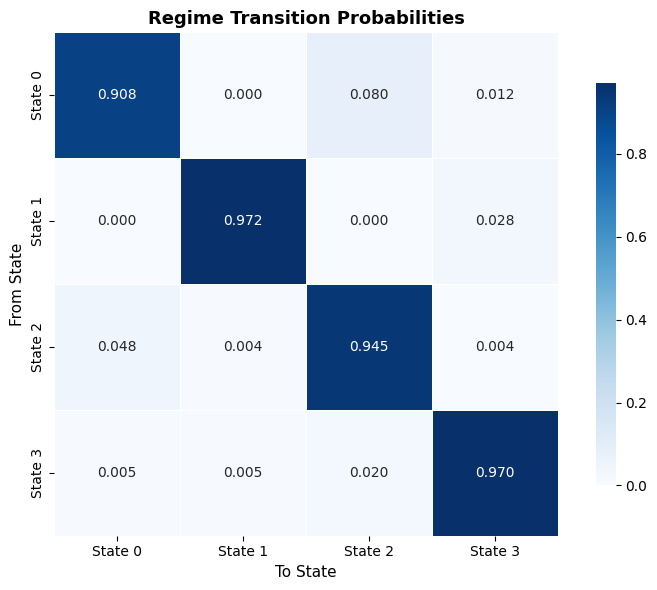

---------End of HMM results for 2010-01-01--------




-------HMM results for 2011-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.217282 -0.001223     -0.145507       -1.694698     287  22.317263   
1      1  0.471389  0.004779      0.313245       -0.847140     241  18.740280   
2      2 -0.059720 -0.048428     -0.039289        0.197508     452  35.147745   
3      3 -0.078126 -0.017846      0.003765        1.920663     306  23.794712   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.812611        0.606456            -0.906184   
1         1.459064        0.858255             1.421953   
2        -0.292870       -1.373807            -0.367133   
3        -0.353584       -0.090904            -0.148636   

   macro_surprise_zscore               economic_label  
0              -1.020413          Stable / Late Cycle  
1              -0.476060  Crisis / USD Funding Stress  
2               0.194878   USD We

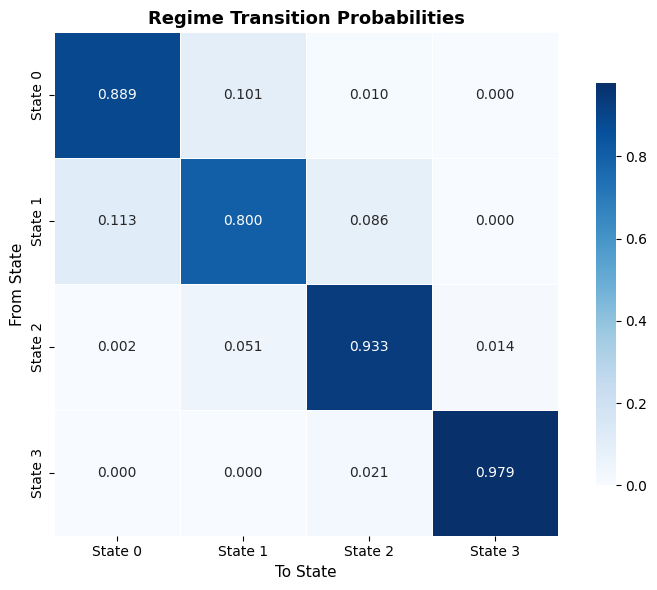

---------End of HMM results for 2011-01-01--------




-------HMM results for 2012-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.032622 -0.006617     -0.110230        0.088659     515  33.948583   
1      1 -0.139229 -0.034437     -0.136468        1.722964     314  20.698748   
2      2 -0.108120 -0.056920      0.152685       -1.537045     523  34.475939   
3      3  0.634138  0.105856      0.172182        1.422748     165  10.876730   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.330619       -0.118866            -0.783955   
1        -0.621518       -0.503917            -0.942458   
2        -0.536631       -0.815109             0.804315   
3         1.488769        1.437893             0.922098   

   macro_surprise_zscore               economic_label  
0              -0.225578      Flattening / Tightening  
1               0.872702  Stable / Positive Surprises  
2              -1.318077     Low 

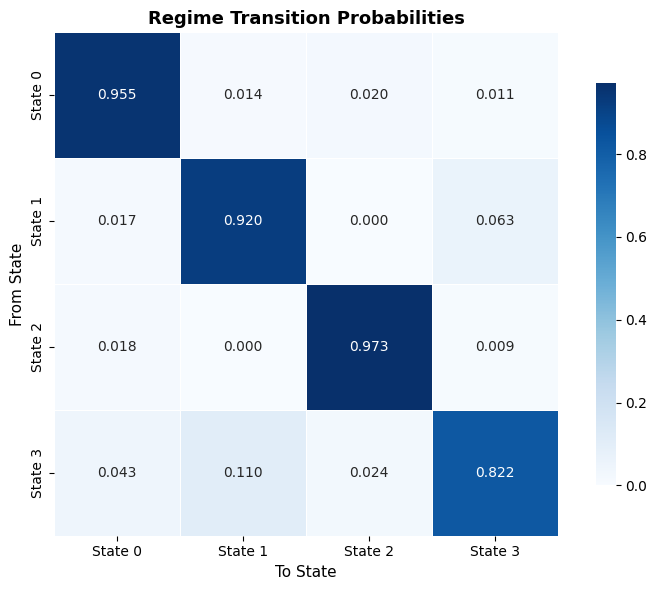

---------End of HMM results for 2012-01-01--------




-------HMM results for 2013-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.025882 -0.029293      0.071708       -1.974436     338  19.492503   
1      1 -0.035313  0.012144      0.126178        2.068528     359  20.703576   
2      2 -0.037632 -0.004751      0.034365       -0.682680     533  30.738178   
3      3  0.031817 -0.033978     -0.151238        0.617723     504  29.065744   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.278534       -0.708820             0.427424   
1        -0.566280        1.207929             0.879904   
2        -0.637048        0.426436             0.117221   
3         1.481862       -0.925546            -1.424548   

   macro_surprise_zscore                 economic_label  
0              -1.142584     USD Weakness / Convergence  
1               1.188435   Stable / Reflationary Growth  
2              -0.397807   

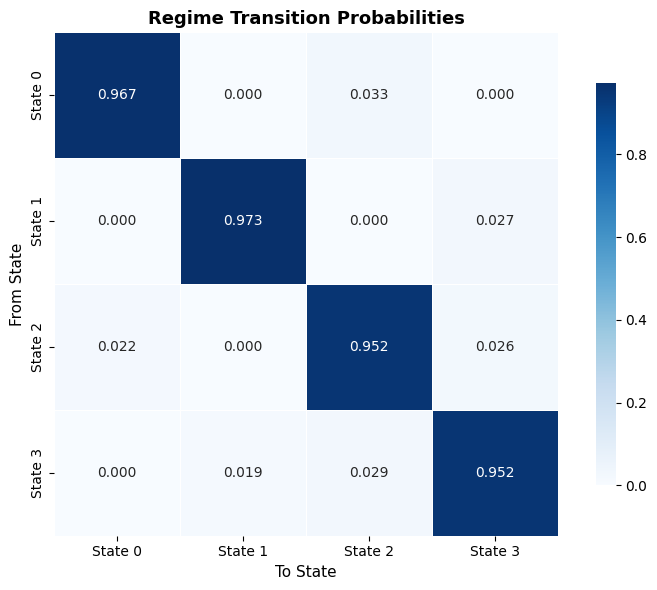

---------End of HMM results for 2013-01-01--------




-------HMM results for 2014-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.080905 -0.016218      0.010624       -0.470186     536  27.208122   
1      1 -0.134541 -0.033759     -0.119662        1.304720     665  33.756345   
2      2 -0.098633  0.005279      0.029688       -1.762467     509  25.837563   
3      3  0.658858  0.043022      0.259452        1.179778     260  13.197970   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.436946       -0.477752            -0.218272   
1        -0.577197       -1.008183            -1.044929   
2        -0.483302        0.172300            -0.097317   
3         1.497445        1.313634             1.360518   

   macro_surprise_zscore               economic_label  
0              -0.364859         Mixed / Transitional  
1               0.849797  Stable / Positive Surprises  
2              -1.249231         

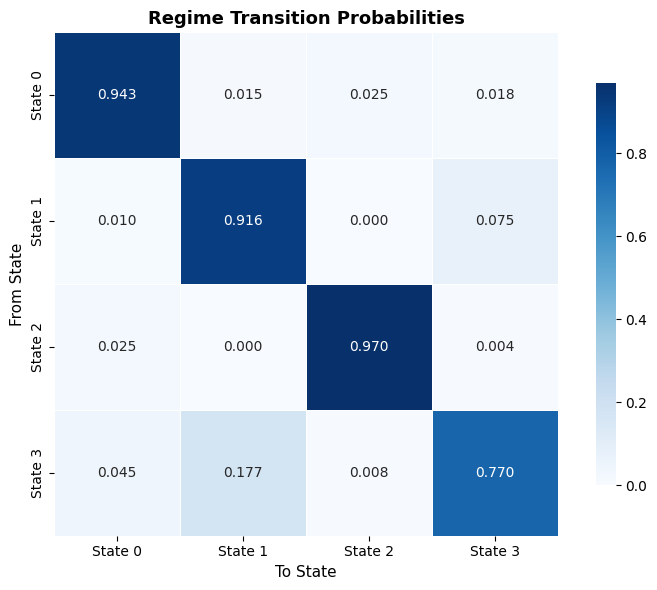

---------End of HMM results for 2014-01-01--------




-------HMM results for 2015-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.004007 -0.021177     -0.116092        1.872754     503  22.811791   
1      1 -0.121023 -0.024563      0.065082       -1.508500     776  35.192744   
2      2 -0.089720  0.025699     -0.064591        0.073395     729  33.061224   
3      3  0.760911  0.087261      0.310711        1.080338     197   8.934240   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.335295       -0.726622            -0.865303   
1        -0.614451       -0.791396             0.085575   
2        -0.539774        0.170145            -0.595006   
3         1.489520        1.347873             1.374734   

   macro_surprise_zscore               economic_label  
0               1.024027   USD Weakness / Convergence  
1              -1.294726     Low Volatility / Risk-On  
2              -0.209914         

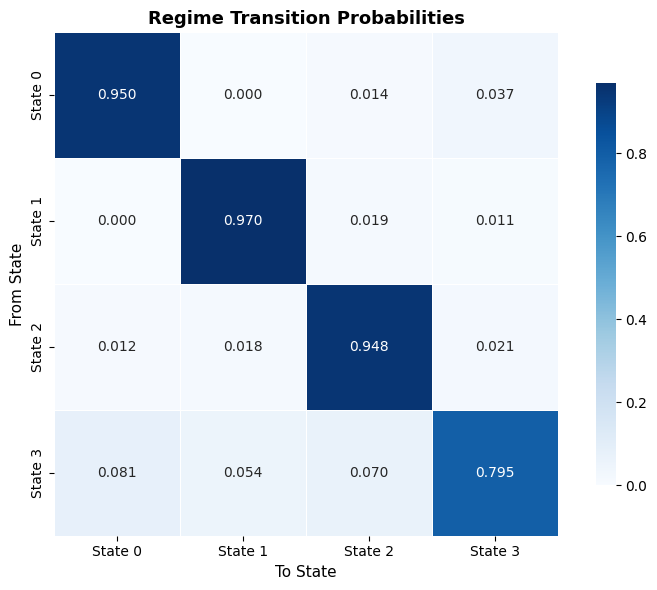

---------End of HMM results for 2015-01-01--------




-------HMM results for 2016-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.119529  0.010291      0.043637       -1.527236     816  33.415233   
1      1 -0.008687 -0.011901     -0.085364        2.019312     485  19.860770   
2      2 -0.046750  0.023311     -0.076706        0.108022     933  38.206388   
3      3  0.675296 -0.001314      0.394719        0.981564     208   8.517609   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.661683        0.342806            -0.113072   
1        -0.361852       -1.121802            -0.686564   
2        -0.464814        1.202095            -0.648070   
3         1.488350       -0.423099             1.447705   

   macro_surprise_zscore              economic_label  
0              -1.280839    Low Volatility / Risk-On  
1               1.081813  USD Weakness / Convergence  
2              -0.191457   USD Stren

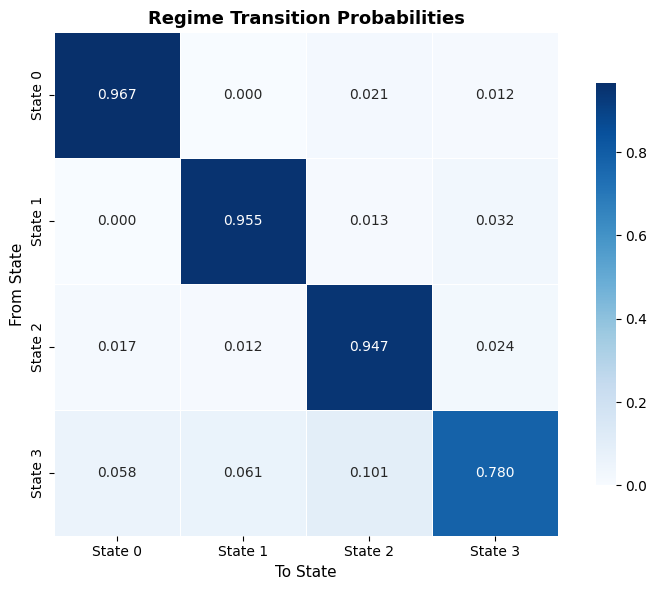

---------End of HMM results for 2016-01-01--------




-------HMM results for 2017-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.043864 -0.016495     -0.148933        1.679016     718  26.711310   
1      1 -0.123888  0.024160     -0.043821       -0.248934     978  36.383929   
2      2 -0.072240  0.023578      0.094961       -1.676360     744  27.678571   
3      3  0.794569 -0.008860      0.349695        1.241890     248   9.226190   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.416177       -1.035643            -0.982554   
1        -0.598656        0.870329            -0.495183   
2        -0.480882        0.843021             0.148307   
3         1.495714       -0.677707             1.329430   

   macro_surprise_zscore                    economic_label  
0               0.937185        USD Weakness / Convergence  
1              -0.326244          Low Volatility / Risk-On  
2              -1.

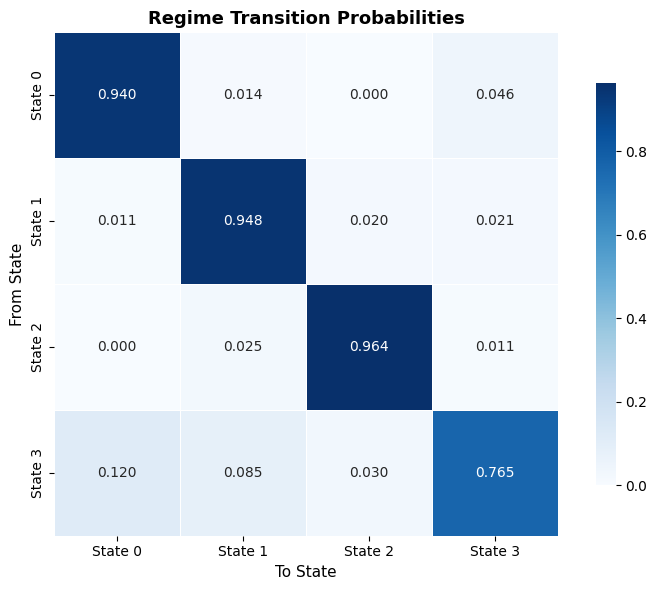

---------End of HMM results for 2017-01-01--------




-------HMM results for 2018-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.070723  0.025322      0.096255       -1.721094     778  26.571038   
1      1  0.725607  0.030503      0.321982        1.068537     271   9.255464   
2      2 -0.114595  0.009806     -0.037231       -0.285780    1051  35.894809   
3      3 -0.052486 -0.037644     -0.135680        1.665600     828  28.278689   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.477765        0.590523             0.176327   
1         1.496864        0.757473             1.316000   
2        -0.586554        0.090519            -0.497633   
3        -0.432544       -1.438515            -0.994693   

   macro_surprise_zscore                    economic_label  
0              -1.261376  USD Strength / Growth Divergence  
1               0.587779       Crisis / USD Funding Stress  
2              -0.

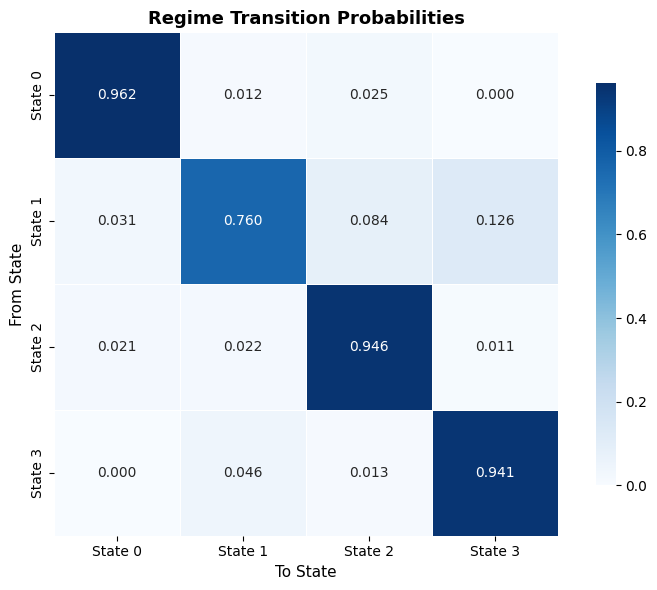

---------End of HMM results for 2018-01-01--------




-------HMM results for 2019-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.073000  0.018815      0.120982        1.823577     772  24.453595   
1      1  0.855492  0.033130      0.333288       -1.023106     299   9.471017   
2      2 -0.136602  0.018095     -0.061230        0.415482    1019  32.277479   
3      3 -0.069294 -0.026981     -0.108201       -1.456600    1067  33.797909   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.456930        0.308439             0.247943   
1         1.496827        0.856939             1.305554   
2        -0.590764        0.280869            -0.659755   
3        -0.449133       -1.446248            -0.893743   

   macro_surprise_zscore              economic_label  
0               1.265042          Positive Surprises  
1              -0.646674    Crisis / Growth Collapse  
2               0.319423         Sta

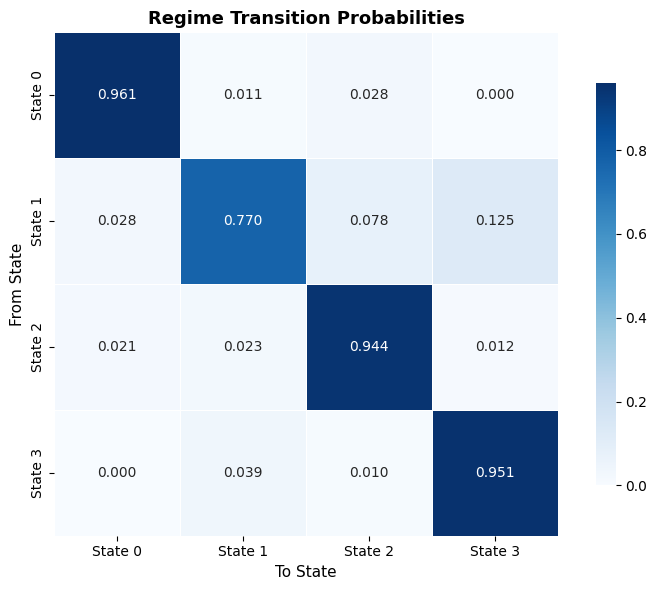

---------End of HMM results for 2019-01-01--------




-------HMM results for 2020-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.088951  0.015544      0.126382        1.814301     834  24.630833   
1      1  0.925112  0.028753      0.490455       -1.013904     307   9.066745   
2      2 -0.067262 -0.021062     -0.123218       -1.459305    1147  33.874778   
3      3 -0.131741  0.013297     -0.089827        0.401266    1098  32.427643   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.485556        0.301647             0.090109   
1         1.497939        0.923150             1.379970   
2        -0.443132       -1.420711            -0.794189   
3        -0.569251        0.195915            -0.675890   

   macro_surprise_zscore              economic_label  
0               1.267234          Positive Surprises  
1              -0.640455    Crisis / Growth Collapse  
2              -0.940888  USD Weakne

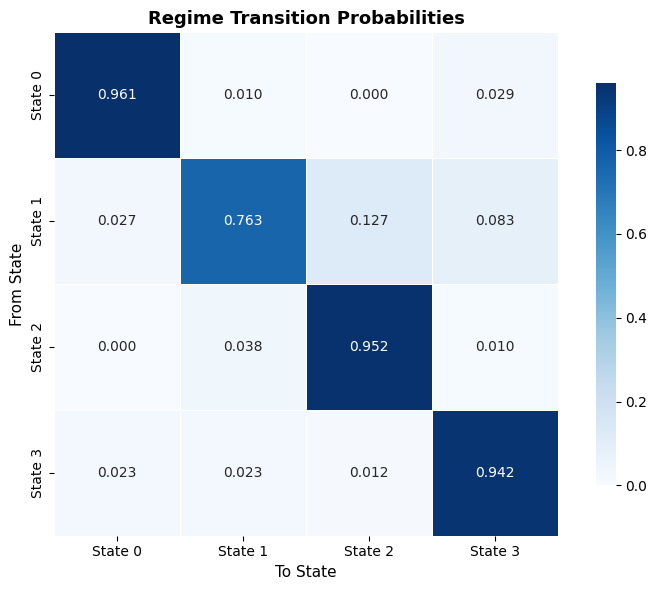

---------End of HMM results for 2020-01-01--------




-------HMM results for 2021-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.033258  0.013524     -0.000085        0.699431    1163  32.207145   
1      1 -0.113311 -0.006657     -0.110809       -1.142765    1454  40.265854   
2      2 -0.206901 -0.053567     -0.005564        2.191177     564  15.618942   
3      3  0.663979  0.047054      0.440132       -0.997166     430  11.908059   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.279105        0.319332            -0.330846   
1        -0.480601       -0.160321            -0.783085   
2        -0.716174       -1.275265            -0.353226   
3         1.475879        1.116254             1.467157   

   macro_surprise_zscore               economic_label  
0               0.324755         Mixed / Transitional  
1              -0.844269        Slowdown / Flattening  
2               1.271389  Stable 

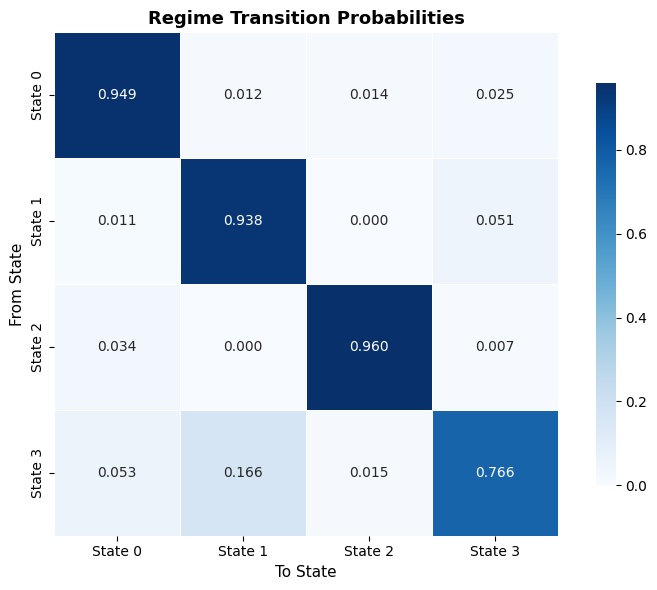

---------End of HMM results for 2021-01-01--------




-------HMM results for 2022-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.106250  0.036370     -0.003091        0.468990    1161  30.258014   
1      1 -0.066300 -0.018533     -0.093610       -1.330679    1416  36.903831   
2      2 -0.092370 -0.023685      0.042406        1.890886     870  22.673964   
3      3  0.643299  0.039511      0.314292       -0.870170     390  10.164191   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.548491        0.817831            -0.387874   
1        -0.439389       -0.788405            -0.903514   
2        -0.510585       -0.939142            -0.128701   
3         1.498465        0.909715             1.420089   

   macro_surprise_zscore               economic_label  
0               0.295801     Low Volatility / Risk-On  
1              -0.944419   USD Weakness / Convergence  
2               1.275682  Stable 

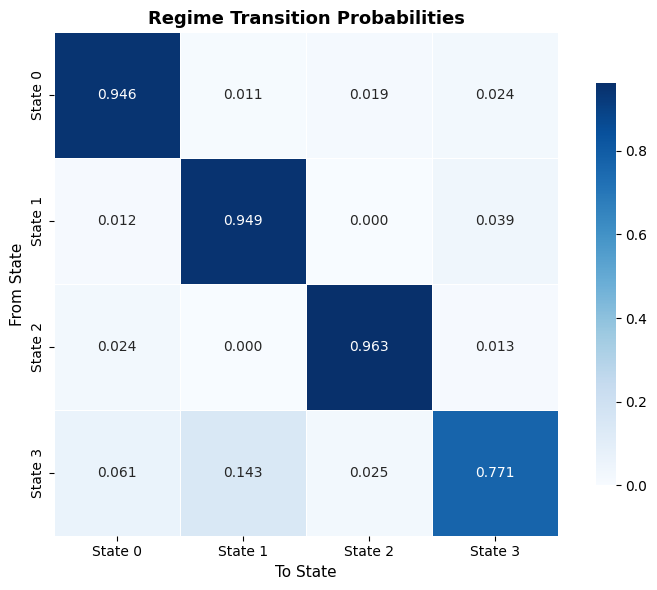

---------End of HMM results for 2022-01-01--------




-------HMM results for 2023-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.044277 -0.012808     -0.083539       -1.356500    1492  36.694540   
1      1 -0.100448  0.025963     -0.000276        0.493904    1254  30.841121   
2      2 -0.116925 -0.005036     -0.008908        1.903897     886  21.790457   
3      3  0.529504  0.020816      0.306589       -0.735854     434  10.673881   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.358929       -1.052666            -0.792676   
1        -0.540168        0.983711            -0.310938   
2        -0.593332       -0.644429            -0.360882   
3         1.492429        0.713384             1.464495   

   macro_surprise_zscore               economic_label  
0              -0.994547   USD Weakness / Convergence  
1               0.289815     Low Volatility / Risk-On  
2               1.268488  Stable 

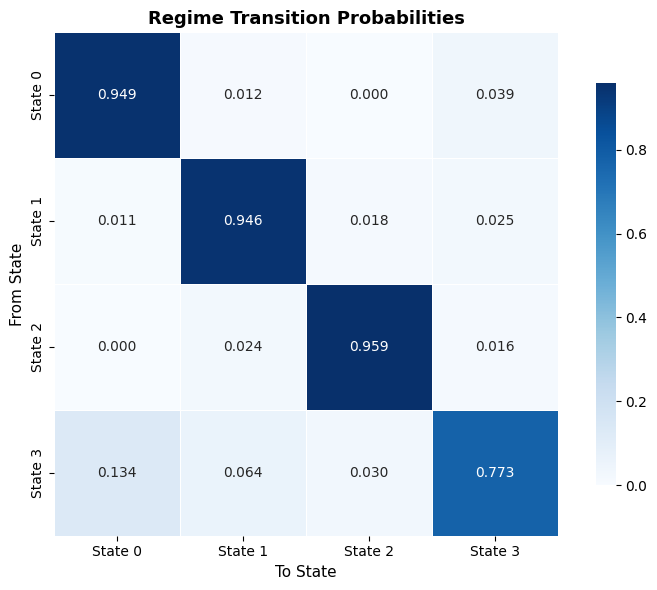

---------End of HMM results for 2023-01-01--------




-------HMM results for 2024-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.167800 -0.008011     -0.017999        1.931555     882  20.540289   
1      1 -0.035003 -0.019594     -0.087934       -1.428930    1495  34.816022   
2      2 -0.063567  0.030565      0.033715        0.471085    1490  34.699581   
3      3  0.467469 -0.007559      0.234818       -0.705146     427   9.944108   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.768072       -0.313814            -0.422813   
1        -0.300353       -0.843558            -0.926986   
2        -0.400958        1.450516            -0.049996   
3         1.469383       -0.293144             1.399795   

   macro_surprise_zscore               economic_label  
0               1.269174  Stable / Positive Surprises  
1              -1.018430   USD Weakness / Convergence  
2               0.274980    USD S

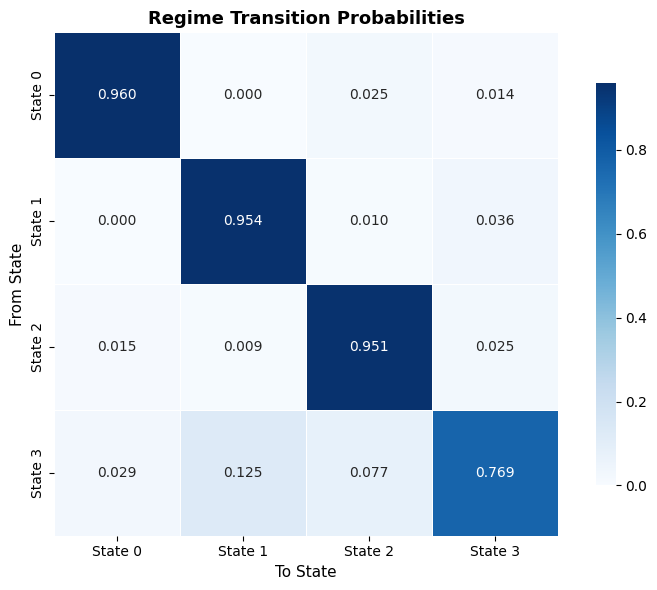

---------End of HMM results for 2024-01-01--------




-------HMM results for 2025-01-01--------
   state  move_chg   dxy_chg  curve_signal  macro_surprise  n_days   pct_days  \
0      0 -0.024678 -0.027916     -0.089727       -2.097517     950  21.045636   
1      1 -0.130961  0.017836     -0.015037        1.239006    1961  43.442623   
2      2 -0.071837 -0.005694     -0.095396       -0.589417    1115  24.700930   
3      3  0.442803  0.036537      0.463663        0.397582     488  10.810811   

   move_chg_zscore  dxy_chg_zscore  curve_signal_zscore  \
0        -0.298590       -1.181128            -0.581242   
1        -0.702809        0.451137            -0.302243   
2        -0.477948       -0.388320            -0.602416   
3         1.479347        1.118311             1.485901   

   macro_surprise_zscore               economic_label  
0              -1.280074   USD Weakness / Convergence  
1               1.047533  Stable / Positive Surprises  
2              -0.228002      Fla

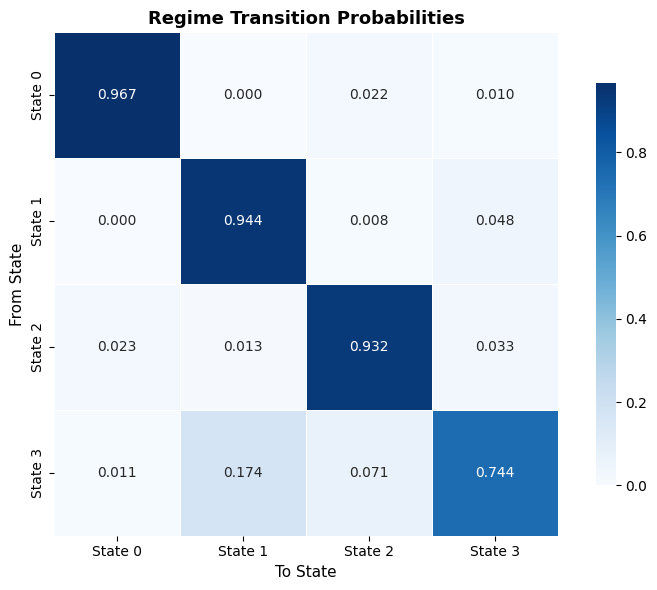

---------End of HMM results for 2025-01-01--------




In [9]:
period_hmm_dict = get_hmm_dict(period_features_dict=period_train_features_dict)

In [10]:
# # save regime probabilities per training window
# for date, hmm_obj in period_hmm_dict.items():
#     regime_prob_path = results_dir / 'training_window_data' / f'regime_probabilities_{date[:4]}.csv'
#     hmm_obj["regime_labels"].to_csv(regime_prob_path, index=False)


---
## Step 3 — Test Regime Inference

### Methodology

With HMM models trained on each expanding window, we now need to assign a regime label to every day in the corresponding test year. The key constraint is that we can only use information available up to the day before the test day — any use of same-day or future data would introduce lookahead bias into the signal.

Our procedure for each test day $t$:
1. Take all training features (2005 to train end) plus all test features up to $t - 1$ (1-day lag)
2. Concatenate into a single historical sequence seen by the model
3. Run `predict_proba` on the full history — the final probability vector gives the regime state distribution as of the last observed day
4. Assign `regime_most_likely = argmax(probs)`, and record `regime_prob_top` and `regime_prob_gap` (gap between top two probabilities) as confidence metrics

**Why the 1-day lag?** Intraday regime classification from same-day data would require knowing the closing values of all four features before executing a trade at close. In practice, features like the macro surprise index may not be available until after market close, so the lag is a realistic execution assumption.

**Why concatenate train + test history?** The HMM uses all seen data to compute the most likely current state — more history gives a better-filtered estimate. Crucially, only the final state probability is used, so including earlier training data improves the accuracy of the current state estimate without leaking forward information.

In [7]:
def infer_test_regime_dict_from_existing_outputs(
    period_test_features_dict,
    period_train_features_dict,
    period_hmm_dict,
    lag_days= 1,
):
    """
    Return {train_end: test_inference_df}.
    Each test date t is inferred with data available only up to t-lag_days.
    """
    test_features_dict = period_test_features_dict.copy()

    out = {}
    for train_end, test_df in test_features_dict.items():
        train_df = period_train_features_dict[train_end].sort_index()
        model = period_hmm_dict[train_end]["model"]
        n_states = period_hmm_dict[train_end]["n_states"]

        rows = []
        for test_day in test_df.index:
            # get the latest day with available data
            asof_day = test_day - pd.Timedelta(days=lag_days)
            hist_test = test_df.loc[test_df.index <= asof_day]
            # entire df of seen data
            hist = pd.concat([train_df, hist_test], axis=0).sort_index()
            if hist.empty:
                continue
            
            # get most likely regime based on last seen data
            probs_last = model.predict_proba(hist.values)[-1]
            row = {
                "train_end": pd.to_datetime(train_end),
                "test_date": test_day,
                "asof_date": hist.index[-1],
                "n_states": n_states,
                "regime_most_likely": int(np.argmax(probs_last)),
            }
            for s in range(n_states):
                row[f"regime_prob_{s}"] = float(probs_last[s])

            sorted_probs = np.sort(probs_last)[::-1]
            row["regime_prob_top"] = float(sorted_probs[0])
            row["regime_prob_gap"] = float(sorted_probs[0] - sorted_probs[1]) if len(sorted_probs) > 1 else np.nan
            rows.append(row)

        out[train_end] = pd.DataFrame(rows).sort_values("test_date").reset_index(drop=True)

    return out

In [12]:
period_test_regime_dict = infer_test_regime_dict_from_existing_outputs(
    period_test_features_dict=period_test_features_dict,
    period_train_features_dict=period_train_features_dict,
    period_hmm_dict=period_hmm_dict,
    lag_days=1,
)

In [13]:
# save regime probabilities per testing window
for date, df in period_test_regime_dict.items():
    regime_prob_path = results_dir / 'testing_window_data' / f'regime_probabilities_{date[:4]}.csv'
    df.to_csv(regime_prob_path, index=False)


### Output

One CSV per test year (16 files total) is saved to `results/testing_window_data/`. Each file contains daily `regime_most_likely`, per-state probabilities, `regime_prob_top`, and `regime_prob_gap`. The probability gap is particularly useful downstream — a small gap (e.g. 0.35 vs 0.33) indicates genuine regime ambiguity and could be used to reduce position sizing or skip trading entirely on uncertain days.

---
## Step 4 — Regime-Conditional Cointegration & Tradability Screening

### The Core Architectural Decision

We test cointegration **within each regime state separately**, not across the full sample. This is the defining design choice of the strategy. Unconditional cointegration tests over 20 years of data can mask regime-specific structural breaks — a pair that appears cointegrated in aggregate may derive all of its mean-reversion from a single calm regime, and fail entirely during stress periods. Trading it unconditionally would expose the book to exactly the wrong environment.

### Three-Condition Tradability Screen

For each (pair, regime, training window) combination, we require:

| Condition | Test | Threshold | Purpose |
|---|---|---|---|
| **Cointegrated** | Fisher combined ADF (spell-level) | p < 0.05 | Spread must be stationary within the regime |
| **Mean-reverting** | AR(1) coefficient sign + significance | α < 0, p < 0.05 | Spread must have demonstrable pull back toward equilibrium |
| **Regime-persistent** | P(regime duration ≥ half-life) | > 0.40 | Regime must last long enough for the trade to complete |

The third condition is a **practical risk filter** that connects statistical properties to economic viability. A spread with a 15-day half-life in a regime that typically lasts 8 days would statistically expect to reverse before completion, generating an exit at a loss on average. By requiring P(duration ≥ half-life) > 40%, we ensure we only trade pairs where the regime clock gives us a reasonable runway.

### Pairs Tested

- USD–EUR 5Y, USD–EUR 10Y
- JPY–AUD 5Y, JPY–AUD 10Y

In [8]:
from src.spreads.cointegration import regime_conditional_cointegration
from src.regimes.utils import get_regime_durations
from src.spreads.mean_reversion import estimate_pooled_mean_reversion

In [9]:
df_master = pd.read_parquet(data_dir / 'master_df.parquet')
df_master.index = pd.to_datetime(df_master.index)

# Pairs to test
pairs = [
    ('USD', 'EUR', '5Y'),
    ('USD', 'EUR', '10Y'),
    ('JPY', 'AUD', '5Y'),
    ('JPY', 'AUD', '10Y')
]

# Helper functions
def get_yield_column(ccy: str, tenor: str) -> str:
    return f'bond_yields__GT{ccy}{tenor} Govt'

def _get_yield_series(df, pairs):
    yield_data = {}

    for ccy_A, ccy_B, tenor in pairs:
        pair_key = f"{ccy_A}-{ccy_B} {tenor}"
        
        col_A = get_yield_column(ccy_A, tenor)
        col_B = get_yield_column(ccy_B, tenor)
        
        yield_data[pair_key] = {
            'y_A': df[col_A],
            'y_B': df[col_B],
            'ccy_A': ccy_A,
            'ccy_B': ccy_B,
            'tenor': tenor,
            'col_A': col_A,
            'col_B': col_B
        }
    return yield_data


def get_tradable_pairs_dict(period_hmm_dict):
    period_tradable_pairs = {}

    for date, hmm_obj in period_hmm_dict.items():
        df = df_master.copy().join(hmm_obj["regime_labels"][["regime_most_likely"]], how="inner")

        yield_data = _get_yield_series(df, pairs)

        durations_map = get_regime_durations(df["regime_most_likely"])
        all_coint_results = {}
        all_pair_results = []

        for pair_key, data in yield_data.items():
            coint_df = regime_conditional_cointegration(
                y_A=data['y_A'],
                y_B=data['y_B'],
                regime_labels=df['regime_most_likely'],
                min_obs=100,
                min_spell_obs=40,
                adf_method='aic',
                alpha=0.05
            )
            all_coint_results[pair_key] = coint_df
        
        for pair_key, data in yield_data.items():
            coint_df = all_coint_results[pair_key]

            for _, row in coint_df.iterrows():
                r = int(row['regime_state'])

                if not row.get('cointegrated'):
                    continue

                mr = estimate_pooled_mean_reversion(
                    y_A=data['y_A'],
                    y_B=data['y_B'],
                    alpha_r=row['alpha'],
                    beta_r=row['hedge_ratio_beta'],
                    regime_series=df['regime_most_likely'],
                    target_state=r
                )

                if not mr['valid']:
                    continue

                hl        = mr['half_life']
                durs      = np.array(durations_map[r])
                median_dur = np.median(durs)
                prob_persist = np.mean(durs >= hl) if np.isfinite(hl) else 0.0

                # Condition flags
                cond_direction   = mr['alpha'] < 0
                cond_significant = mr['p_value'] < 0.05
                cond_persistent  = prob_persist > 0.4
                is_tradable      = cond_direction and cond_significant and cond_persistent

                all_pair_results.append({
                    'pair_id': pair_key,
                    'y_col': data['col_A'],
                    'x_col': data['col_B'],
                    'tenor': data['tenor'],            
                    'ccy_leg_1': data['ccy_A'],          
                    'ccy_leg_2': data['ccy_B'],        
                    'tradable_regimes': f"[{r}]",      
                    'cointegration_source': 'HMM',   
                    'status': 'approved' if is_tradable else 'rejected', 
                    'regime': r,
                    'fisher_pval': row['fisher_pval'],
                    'beta_r': row['hedge_ratio_beta'],
                    'alpha_r': row['alpha'],
                    'ar1_alpha': mr['alpha'], 
                    'ar1_pval': mr['p_value'],
                    'half_life': hl, 
                    'median_duration': median_dur,
                    'prob_persistence': prob_persist, 
                    'is_tradable': is_tradable
                })

        period_tradable_pairs[date] = all_pair_results
        
    return period_tradable_pairs
        


In [16]:
period_tradable_pairs = get_tradable_pairs_dict(period_hmm_dict)

In [17]:
def build_tradable_regime_df(period_tradable_pairs: dict, all_pair_ids=None) -> pd.DataFrame:
    # Rows
    dates = sorted(period_tradable_pairs.keys())

    # Columns (all pair_ids seen across all dates, unless you pass a fixed list)
    if all_pair_ids is None:
        all_pair_ids = sorted({
            rec["pair_id"]
            for date_rows in period_tradable_pairs.values()
            for rec in date_rows
        })

    table = {}
    for d in dates:
        row = {pair_id: [] for pair_id in all_pair_ids}

        for rec in period_tradable_pairs.get(d, []):
            if bool(rec.get("is_tradable", False)):
                pair_id = rec["pair_id"]
                regime = int(rec["regime"])
                row[pair_id].append(regime)

        # dedupe + sort regimes per pair/date
        for pair_id in row:
            row[pair_id] = sorted(set(row[pair_id]))

        table[d] = row

    return pd.DataFrame.from_dict(table, orient="index")[all_pair_ids]

tradable_regimes_df = build_tradable_regime_df(period_tradable_pairs)

In [18]:
# save tradable pairs to csv
tradable_pairs_path = results_dir / 'training_window_data' / 'tradable_pairs_by_window.csv'

tradable_regimes_df.to_csv(tradable_pairs_path, index=True)

In [19]:
tradable_regimes_df

,JPY-AUD 10Y,JPY-AUD 5Y,USD-EUR 10Y,USD-EUR 5Y
2010-01-01,"[0, 1]",[2],[],[]
2011-01-01,[],[],[],[2]
2012-01-01,[2],[],"[0, 2]",[]
2013-01-01,[0],[2],[3],[2]
2014-01-01,[2],[],[0],[0]
2015-01-01,[1],[],[],[]
2016-01-01,[0],[0],[1],[2]
2017-01-01,[],[],[1],[]
2018-01-01,[0],[],"[0, 2]",[]
2019-01-01,[],[],"[0, 2]",[]


### Tradable Pairs Results

Each cell shows the regime state(s) in which that pair passes all three tradability conditions for the given test year. An empty list `[]` means no regime passed the screen — the pair is not traded that year.

**Key observations:**

**USD–EUR 10Y is the most consistently tradable pair**, active in 12 out of 16 test years. This reflects the deep structural linkage between US and European rates — both markets are dominated by similar macro forces (global growth, inflation expectations, central bank credibility) that keep the long-run relationship mean-reverting, though the specific regime in which this holds shifts over time.

**USD–EUR 5Y is more selective**, active in only 7 years. The 5-year point is more sensitive to near-term rate expectations and central bank forward guidance, meaning it is more prone to persistent dislocations when policy paths diverge sharply (e.g. 2014–2016 when the Fed was hiking while the ECB went negative).

**JPY–AUD pairs are episodic**, concentrated in specific windows. These pairs are more exotic — JPY is driven by BoJ yield curve control and carry trade dynamics, AUD by commodity cycles and RBA policy. Their cointegration tends to hold in calm, carry-friendly regimes but breaks down quickly when risk-off sentiment triggers JPY safe-haven flows. This explains the gaps in 2011, 2015, and 2017–2019.

**2022–2024 shows broad tradability across all pairs.** The synchronised global rate hiking cycle from 2022 onwards created a period of high but stable cross-country yield differentials, with central banks moving in similar directions. This regime is exactly when regime-conditional RV performs well — large, mean-reverting spreads with predictable reversion dynamics.

**The `[]` entries are as informative as the non-empty ones.** Years like 2015 (USD–EUR, JPY–AUD) correspond to extreme policy divergence (ECB QE vs Fed liftoff) where spreads were directional, not mean-reverting. The screen correctly identifies these as untradable and keeps the strategy out of a losing environment.

In [20]:
period_tradable_pairs

{'2010-01-01': [{'pair_id': 'JPY-AUD 5Y',
   'y_col': 'bond_yields__GTJPY5Y Govt',
   'x_col': 'bond_yields__GTAUD5Y Govt',
   'tenor': '5Y',
   'ccy_leg_1': 'JPY',
   'ccy_leg_2': 'AUD',
   'tradable_regimes': '[2]',
   'cointegration_source': 'HMM',
   'status': 'approved',
   'regime': 2,
   'fisher_pval': 0.03231838592656622,
   'beta_r': 0.31524262301853045,
   'alpha_r': -0.6800028615632696,
   'ar1_alpha': np.float64(-0.08851793331714419),
   'ar1_pval': np.float64(5.830795192809688e-06),
   'half_life': np.float64(7.83058477061954),
   'median_duration': np.float64(7.0),
   'prob_persistence': np.float64(0.45454545454545453),
   'is_tradable': np.True_},
  {'pair_id': 'JPY-AUD 10Y',
   'y_col': 'bond_yields__GTJPY10Y Govt',
   'x_col': 'bond_yields__GTAUD10Y Govt',
   'tenor': '10Y',
   'ccy_leg_1': 'JPY',
   'ccy_leg_2': 'AUD',
   'tradable_regimes': '[0]',
   'cointegration_source': 'HMM',
   'status': 'approved',
   'regime': 0,
   'fisher_pval': 0.009738680973167732,
   'be

---
## Step 5 — Dynamic Hedge Ratio via Kalman Filter

### Why Not a Static OLS Hedge Ratio?

A static OLS regression over the full sample would produce a single fixed hedge ratio for each pair — say, β = 0.85 for USD–EUR 5Y. This assumes the relationship between the two yield series is constant over 20 years, which is empirically false. The transmission of monetary policy across borders evolves with:
- **Central bank divergence** (Fed hiking while ECB holds changes how much US rates drive EUR rates)
- **Capital flow regimes** (risk-on vs. risk-off periods alter the correlation structure)
- **Global QE and yield curve control** (BoJ YCC materially distorted the JPY–AUD relationship post-2016)

A static hedge would be progressively miscalibrated over time, producing a spread series that is not actually mean-reverting — the "spread" would contain a systematic trend from the unmodelled hedge ratio drift.

### Kalman State-Space Model

We model the relationship as:

$$y_t = \alpha_t + \beta_t x_t + \varepsilon_t, \qquad \varepsilon_t \sim \mathcal{N}(0,\, \sigma^2_\varepsilon)$$

where $\alpha_t$ (intercept) and $\beta_t$ (hedge ratio) both follow random walks:

$$[\alpha_t, \beta_t]^\top = [\alpha_{t-1}, \beta_{t-1}]^\top + \eta_t, \qquad \eta_t \sim \mathcal{N}(0,\, Q)$$

The state noise covariance $Q = \delta \cdot I$ is controlled by the parameter δ = 1e-6, which we set to reflect our prior that the relationship **evolves slowly** — it shifts over quarters and years, not days. A larger δ would allow rapid jumps in the hedge ratio, which would overfit to short-term noise.

### Key Outputs

| Column | Interpretation |
|---|---|
| `beta_t` | Time-varying hedge ratio — how many units of x to sell per unit of y |
| `alpha_t` | Time-varying intercept — persistent structural spread level |
| `spread_t` | Residual: $y_t - \alpha_t - \beta_t x_t$ — the mean-reverting signal |
| `innovation_z_t` | Standardised one-step forecast error — the **trading signal** in NB18–20 |

**Why `innovation_z_t` as the signal?** The Kalman innovation is the standardised difference between the observed spread and the filter's own prediction. Unlike a rolling Z-score of `spread_t`, it is normalised by the filter's estimated observation uncertainty at each step — making it a more statistically rigorous signal that accounts for the time-varying confidence in the spread estimate.

**Lookahead guarantee:** The Kalman filter is causal by construction. At each time step, the estimate of $[\alpha_t, \beta_t]$ uses only observations up to and including time $t$. There is no lookahead bias in any of the outputs.

In [21]:
from src.spreads.kalman import run_kalman_for_contract

yields_path = project_root / "DATA" / "processed" / "master_df.parquet"
yields = pd.read_parquet(yields_path)

In [22]:
# since we have determined that every pair is tradable in at least 1 regime, we can just find hedge ratios for every pair
for y, x, tenor in pairs:
    run_kalman_for_contract(
        yields_df=yields,
        pair_id = f"{y}-{x} {tenor}",
        y_col = get_yield_column(y, tenor),
        x_col = get_yield_column(x, tenor),
        out_dir=str(project_root/"results"/"spreads")
    )

/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/spreads/kalman.py:72: RuntimeWarning: invalid value encountered in divide
  innovation / np.sqrt(innovation_var),
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/spreads/kalman.py:72: RuntimeWarning: invalid value encountered in divide
  innovation / np.sqrt(innovation_var),
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/spreads/kalman.py:72: RuntimeWarning: invalid value encountered in divide
  innovation / np.sqrt(innovation_var),
/Users/test/Desktop/rates project/Cross-Country-Rates-Relative-Value-NUSInvest2526/src/spreads/kalman.py:72: RuntimeWarning: invalid value encountered in divide
  innovation / np.sqrt(innovation_var),


### Kalman Filter Output

Four parquet files are saved to `results/spreads/`, one per pair. The `RuntimeWarning: invalid value encountered in divide` on the first few observations is expected and benign — it arises because the Kalman filter's innovation variance is initialised to zero before the first update, causing a division by zero on day 1. The filter converges to stable estimates within a few days and these initial observations are discarded in backtesting.

The resulting `innovation_z_t` series is the primary signal consumed by NB18, NB19, and NB20. Entries of `±2.0` or beyond indicate the spread has moved more than 2 standard deviations outside what the Kalman model predicts — these are the dislocation events the strategy trades. Values within `±0.5` indicate the spread has reverted close to the filtered equilibrium — these trigger exits.